# Diabetes Prediction Using Random Forest

1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

from itertools import cycle

2. Load the Dataset

In [ ]:
df = pd.read_csv("Dataset of Diabetes.csv")


In [ ]:
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


3. Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


4. Data Preprosessing

In [ ]:
df["CLASS"] = df["CLASS"].str.strip()

In [ ]:
print(df["CLASS"].unique())

['N' 'P' 'Y']


In [ ]:
df.isnull().sum()

,0
ID,0
No_Pation,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0


* Encode Gender




In [ ]:
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

In [ ]:
print(df["Gender"].unique())

for value in df["Gender"].unique():
    print(repr(value))

[0 1]
np.int64(0)
np.int64(1)


* Encode Target Variable

In [ ]:
class_encoder = LabelEncoder()

df["CLASS"] = class_encoder.fit_transform(df["CLASS"])

In [ ]:
print(df['CLASS'].unique())

[0 1 2]


* Remove Columns

In [ ]:
df = df.drop(["ID","No_Pation"], axis=1)

* Define Features and Target

In [ ]:
X = df.drop("CLASS", axis=1)

y = df["CLASS"]

# Train-Test Split

* 80% training

* 20% testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

4. Exploratory Data Analysis (EDA)

* Class Distribution

/tmp/ipykernel_1047/132970391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="CLASS", data=df, palette="Set2")


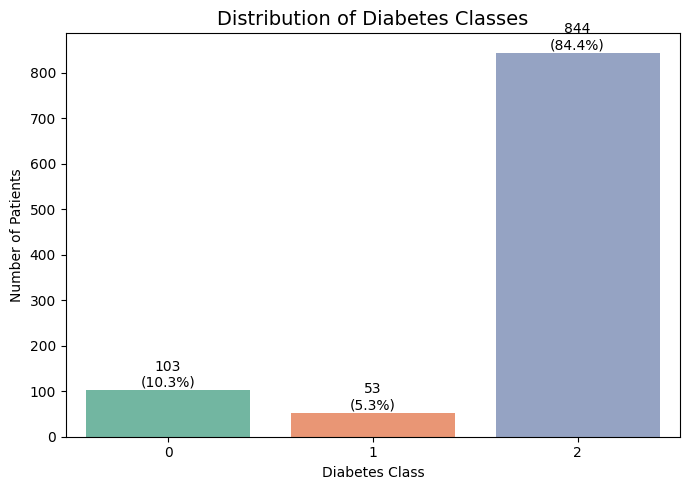

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x="CLASS", data=df, palette="Set2")

# Total number of patients
total = len(df)

# Add count and percentage on each bar
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f'{count}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribution of Diabetes Classes", fontsize=14)
plt.xlabel("Diabetes Class")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Results :

> * **Class 0 (Non-Diabetic):** = 103 patients
> * **Class 1 (Prediabetic):** = 53 patients
> * **Class 2 (Diabetic):** = 844 patients

* Gender Distribution

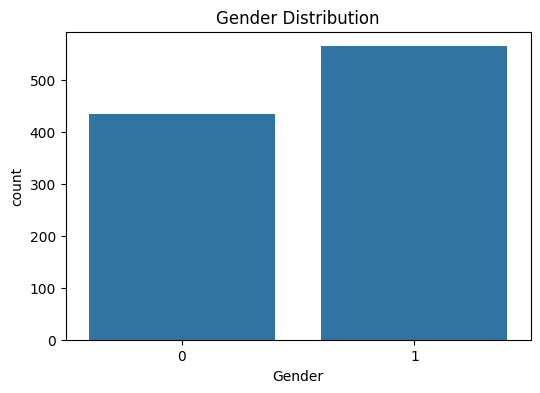

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

* Age Distribution

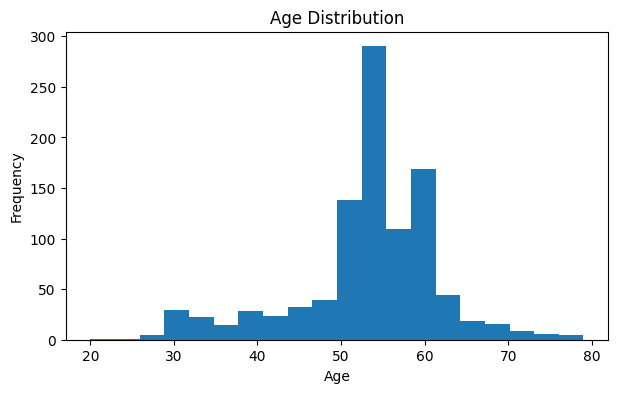

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(df["AGE"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

* BMI Distribution

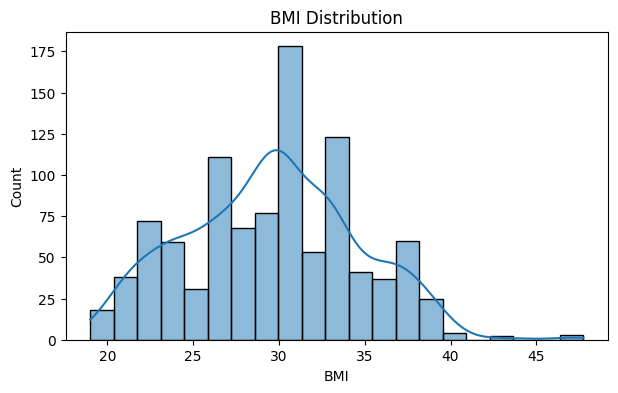

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(df["BMI"], kde=True)

plt.title("BMI Distribution")

plt.show()

* Histograms

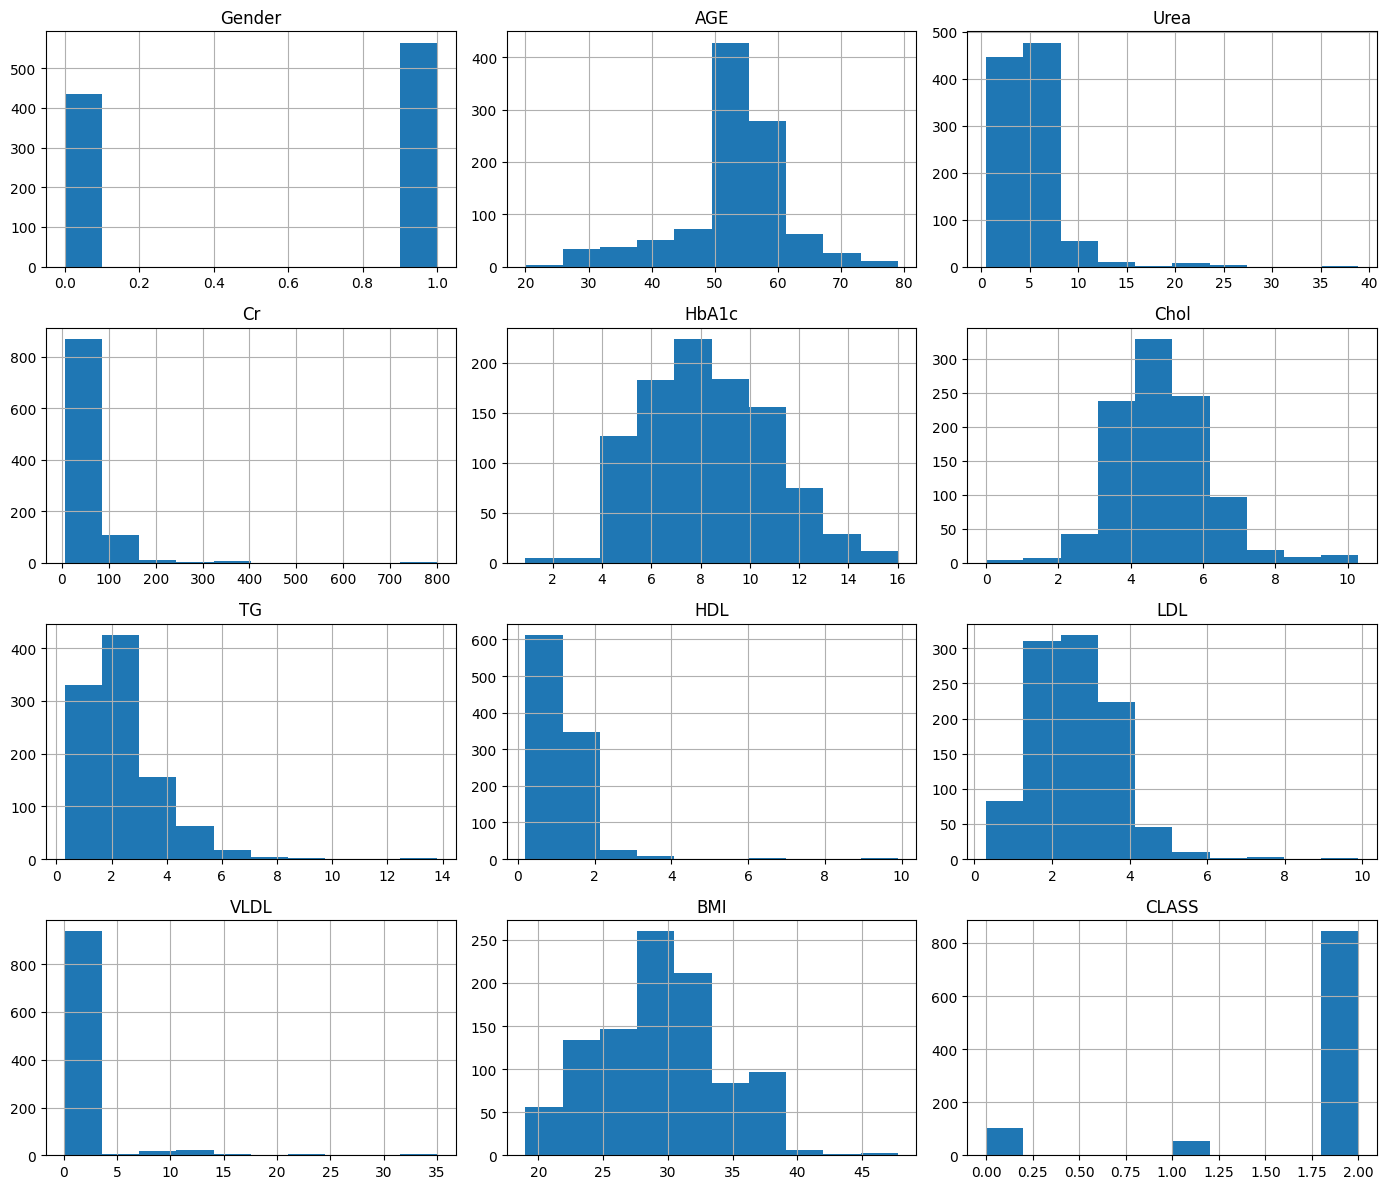

In [ ]:
df.hist(figsize=(14,12))

plt.tight_layout()

plt.show()

* Boxplots

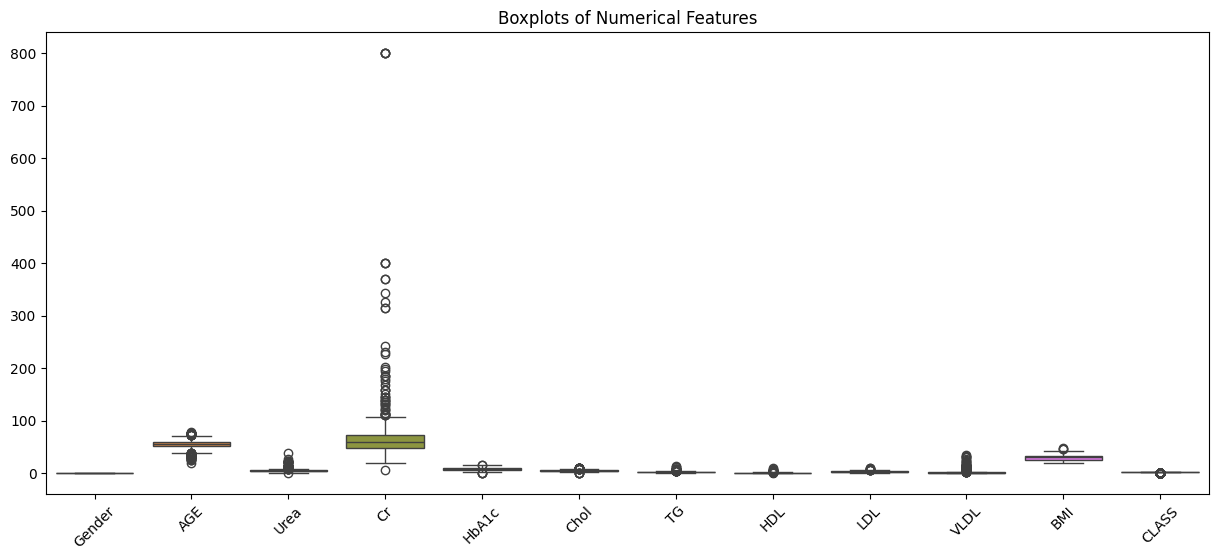

In [ ]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=45)

plt.title("Boxplots of Numerical Features")

plt.show()

* Correlation Heatmap

In [ ]:
temp = df.copy()

temp["Gender"] = LabelEncoder().fit_transform(temp["Gender"])

temp["CLASS"] = LabelEncoder().fit_transform(temp["CLASS"])

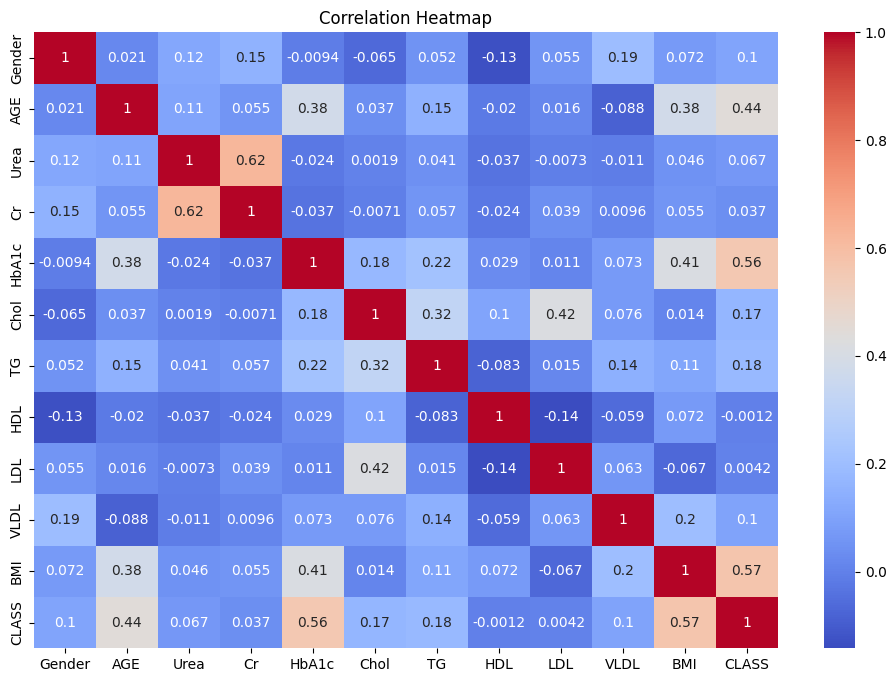

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(temp.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Hyperparameter Tuning

In [ ]:
parameters = {

    "n_estimators":[100,200,300],

    "max_depth":[None,5,10,20],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]
}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


Train the Random Forest Model

In [ ]:
model = grid.best_estimator_

model.fit(X_train,y_train)

RandomForestClassifier(min_samples_split=5, random_state=42)

Make Predictions

In [ ]:
y_pred = model.predict(X_test)

Model Evaluation

Accuracy

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.995


Precision

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:",precision)

Precision: 0.9950294117647058


Recall

In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:",recall)

Recall: 0.995


F1-score

In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:",f1)

F1 Score: 0.9948757956839


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.90      0.95        10
           2       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



* Confusion Matrix

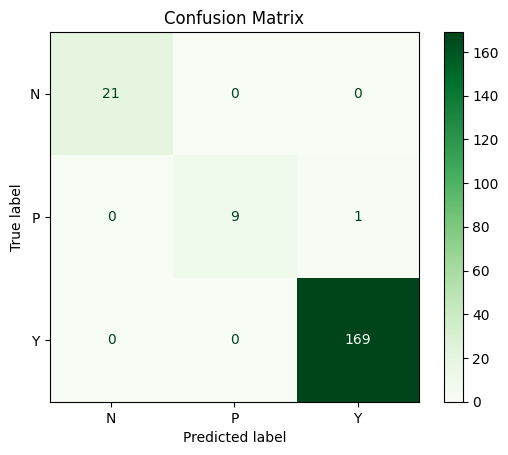

In [ ]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_encoder.classes_
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix")

plt.show()

* Multiclass ROC Curve

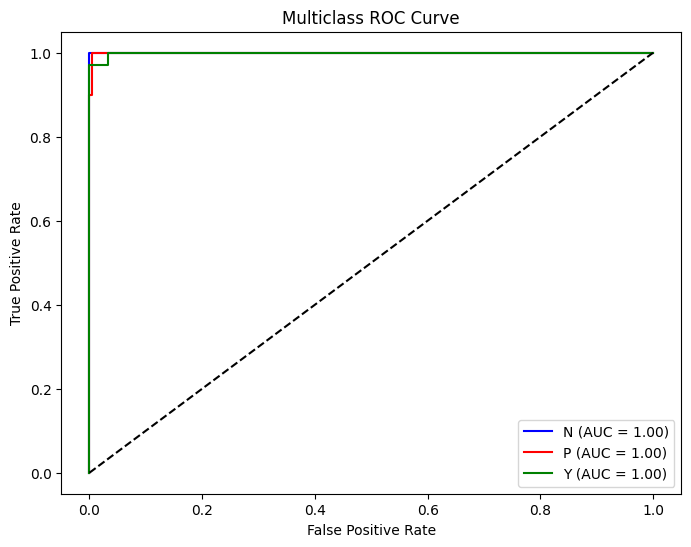

In [ ]:
classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

colors = cycle(["blue","red","green"])

for i, color in zip(range(len(classes)), colors):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        label=f"{class_encoder.classes_[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curve")

plt.legend()

plt.show()

* Feature Importance

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,HbA1c,0.338479
10,BMI,0.280787
1,AGE,0.113330
5,Chol,0.068106
6,TG,0.046586
9,VLDL,0.043696
8,LDL,0.035188
2,Urea,0.024807
3,Cr,0.023436
7,HDL,0.020969


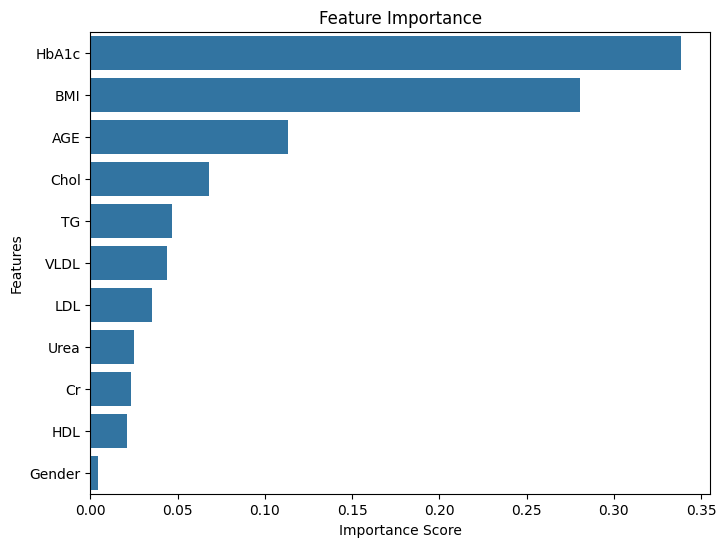

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

* Final Results Table

In [ ]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Value
0,Accuracy,0.995000
1,Precision,0.995029
2,Recall,0.995000
3,F1 Score,0.994876


In [ ]:
import joblib

joblib.dump(model, "random_forest_model.joblib")
joblib.dump(class_encoder, "label_encoder.joblib")

['label_encoder.joblib']

In [ ]:
from google.colab import files

files.download("random_forest_model.joblib")
files.download("label_encoder.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>